In [1]:
import pandas as pd
import numpy as np

In [2]:
X_tf = np.load("X_tf.npy")
y_tf = np.load("y_tf.npy")

print(X_tf.shape)
print(y_tf.shape)


(21799, 12, 1000)
(21799, 52)


In [3]:
#pip install PyWavelets


In [4]:
import numpy as np
from scipy.signal import butter, filtfilt

def high_pass_filter(signal, fs, cutoff=0.5, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, signal)


In [5]:
fs = 100  # sampling frequency

X_hpf = np.zeros_like(X_tf)

for i in range(X_tf.shape[0]):      # 21799 samples
    for lead in range(X_tf.shape[1]):  # 12 leads
        X_hpf[i, lead] = high_pass_filter(
            X_tf[i, lead], fs
        )


In [6]:
X_hpf.shape

(21799, 12, 1000)

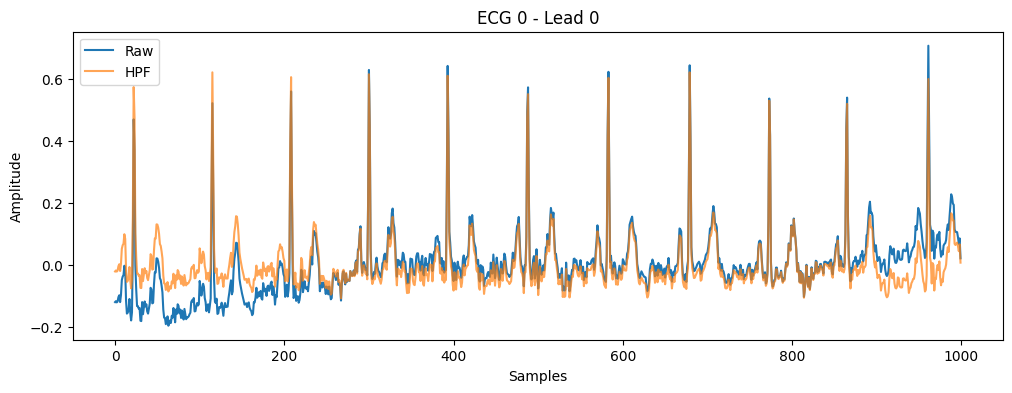

In [17]:
import matplotlib.pyplot as plt

i = 0      # first ECG
lead = 0   # first lead

plt.figure(figsize=(12,4))
plt.plot(X_tf[i, lead], label="Raw")
plt.plot(X_hpf[i, lead], label="HPF", alpha=0.7)
plt.legend()
plt.title("ECG 0 - Lead 0")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [7]:
import numpy as np

def z_score(signal):
    mean = np.mean(signal)
    std = np.std(signal) + 1e-8   # avoid divide-by-zero
    return (signal - mean) / std

X_z = np.zeros_like(X_hpf)

for i in range(X_hpf.shape[0]):        # 21799 ECGs
    for lead in range(X_hpf.shape[1]): # 12 leads
        X_z[i, lead] = z_score(X_hpf[i, lead])


In [8]:
X_z.shape

(21799, 12, 1000)

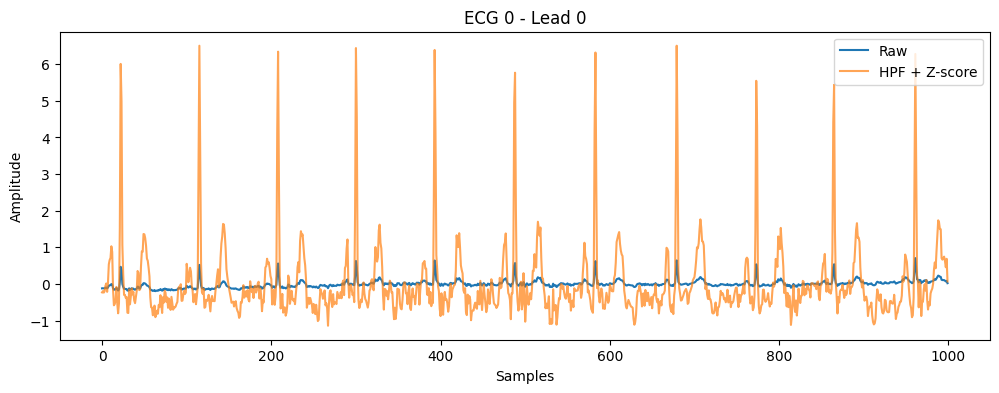

In [9]:
import matplotlib.pyplot as plt

i = 0      # first ECG
lead = 0   # first lead

plt.figure(figsize=(12,4))
plt.plot(X_tf[i, lead], label="Raw")
plt.plot(X_z[i, lead], label="HPF + Z-score", alpha=0.7)
plt.legend()
plt.title("ECG 0 - Lead 0")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [10]:
import pywt
import numpy as np

def apply_dwt(signal, wavelet='db4', level=5):
    """
    signal: shape (1000,)
    returns: list of coefficients [A5, D5, D4, D3, D2, D1]
    """
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    return coeffs


X_dwt = []

for i in range(X_z.shape[0]):          # 21799 ECGs
    sample_coeffs = []
    for lead in range(X_z.shape[1]):   # 12 leads
        coeffs = apply_dwt(X_z[i, lead])
        sample_coeffs.append(coeffs)
    X_dwt.append(sample_coeffs)

X_dwt = np.array(X_dwt, dtype=object)


In [11]:
X_dwt.shape


(21799, 12, 6)

In [12]:
i = 0
lead = 7  # V2

A5, D5, D4, D3, D2, D1 = X_dwt[i][lead]

print("A5 energy:", np.sum(A5**2))
print("D5 energy:", np.sum(D5**2))
print("D4 energy:", np.sum(D4**2))
print("D3 energy:", np.sum(D3**2))
print("D2 energy:", np.sum(D2**2))
print("D1 energy:", np.sum(D1**2))

A5 energy: 67.24103946828413
D5 energy: 212.95211677180887
D4 energy: 116.43819884134648
D3 energy: 325.70049784154804
D2 energy: 236.23067641826884
D1 energy: 63.59716193890125


now it is proved that my signal is clkean ,no need of denoising 

In [13]:
import numpy as np
import pywt

def dwt_denoise_from_coeffs(coeffs, wavelet='db4'):
    """
    coeffs: [A5, D5, D4, D3, D2, D1]
    returns: denoised 1D signal
    """
    A5, D5, D4, D3, D2, D1 = coeffs

    # Estimate noise sigma from D1
    sigma = np.median(np.abs(D1)) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(D1)))

    # Apply soft threshold to noisy bands
    D1_d = pywt.threshold(D1, uthresh, mode='soft')
    D2_d = pywt.threshold(D2, uthresh, mode='soft')

    # Keep other bands unchanged
    coeffs_denoised = [A5, D5, D4, D3, D2_d, D1_d]

    # Reconstruct signal
    signal_denoised = pywt.waverec(coeffs_denoised, wavelet)

    return signal_denoised


In [14]:
X_denoised = np.zeros((X_dwt.shape[0], X_dwt.shape[1], 1000))

for i in range(X_dwt.shape[0]):          # 21799 ECGs
    for lead in range(X_dwt.shape[1]):   # 12 leads
        clean_signal = dwt_denoise_from_coeffs(X_dwt[i, lead])
        X_denoised[i, lead] = clean_signal[:1000]  # safety crop


/home/user/.local/lib/python3.8/site-packages/pywt/_thresholding.py:23: RuntimeWarning: invalid value encountered in divide
  thresholded = (1 - value/magnitude)


In [15]:
print(X_denoised.shape)


(21799, 12, 1000)


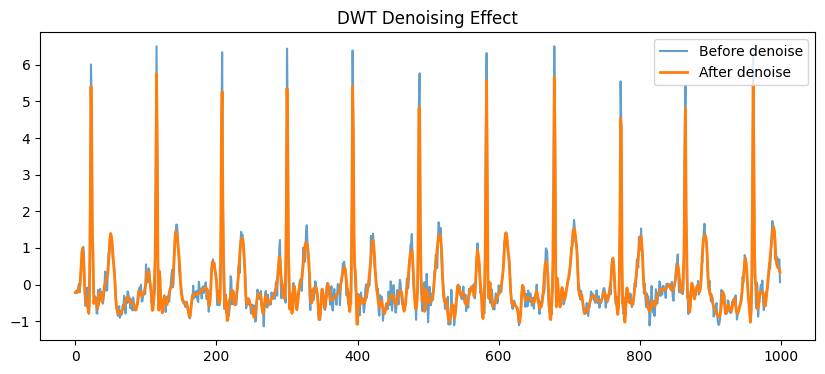

In [16]:
import matplotlib.pyplot as plt

lead = 0
i = 0

plt.figure(figsize=(10,4))
plt.plot(X_z[i, lead], label="Before denoise", alpha=0.7)
plt.plot(X_denoised[i, lead], label="After denoise", linewidth=2)
plt.legend()
plt.title("DWT Denoising Effect")
plt.show()
